In [1]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

In [287]:
from scipy.io import loadmat

sta = loadmat(RAW_DIR / "dual" / "sta_awake_sorted.mat")['sta_sorted']
sta_t = loadmat(RAW_DIR / "dual" / "sta_t.mat")['sta_t'].squeeze()
tsi_sorted = loadmat(RAW_DIR / "dual" / "tsi_sorted.mat")['tsi_sorted'].squeeze()

sta = nap.TsdFrame(t=sta_t, d=sta.T)
sta.save(PROCESSED_DIR / "dual" / "sta_awake_sorted.npz")
np.save(PROCESSED_DIR / "dual" / "tsi_sorted.npy", tsi_sorted)

In [ ]:
tsi = []

sta_awake = []
sta_nrem = []
sta_nrem_all = []

sweeps = []
virtual_hd = []

for mouse_id in MOUSE_IDS:
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")  
    sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    sweeps.append(nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sweeps.npz"))
    tsi.append(turn_units['turn_index'])

    sta_awake.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_awake.npz"))
    sta_nrem.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem.npz"))
    sta_nrem_all.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem_all.npz"))

tsi = np.concatenate(tsi)
order = np.argsort(tsi)
zero_cross = np.argmin(np.abs(tsi[order])).item()

sta_awake = np.rad2deg(np.column_stack(sta_awake))
sta_nrem = np.rad2deg(np.column_stack(sta_nrem))
sta_nrem_all = np.rad2deg(np.column_stack(sta_nrem_all))

# sta_nrem = np.nan_to_num(sta_nrem, nan=0)
# sta_nrem_all = np.nan_to_num(sta_nrem_all, nan=0)

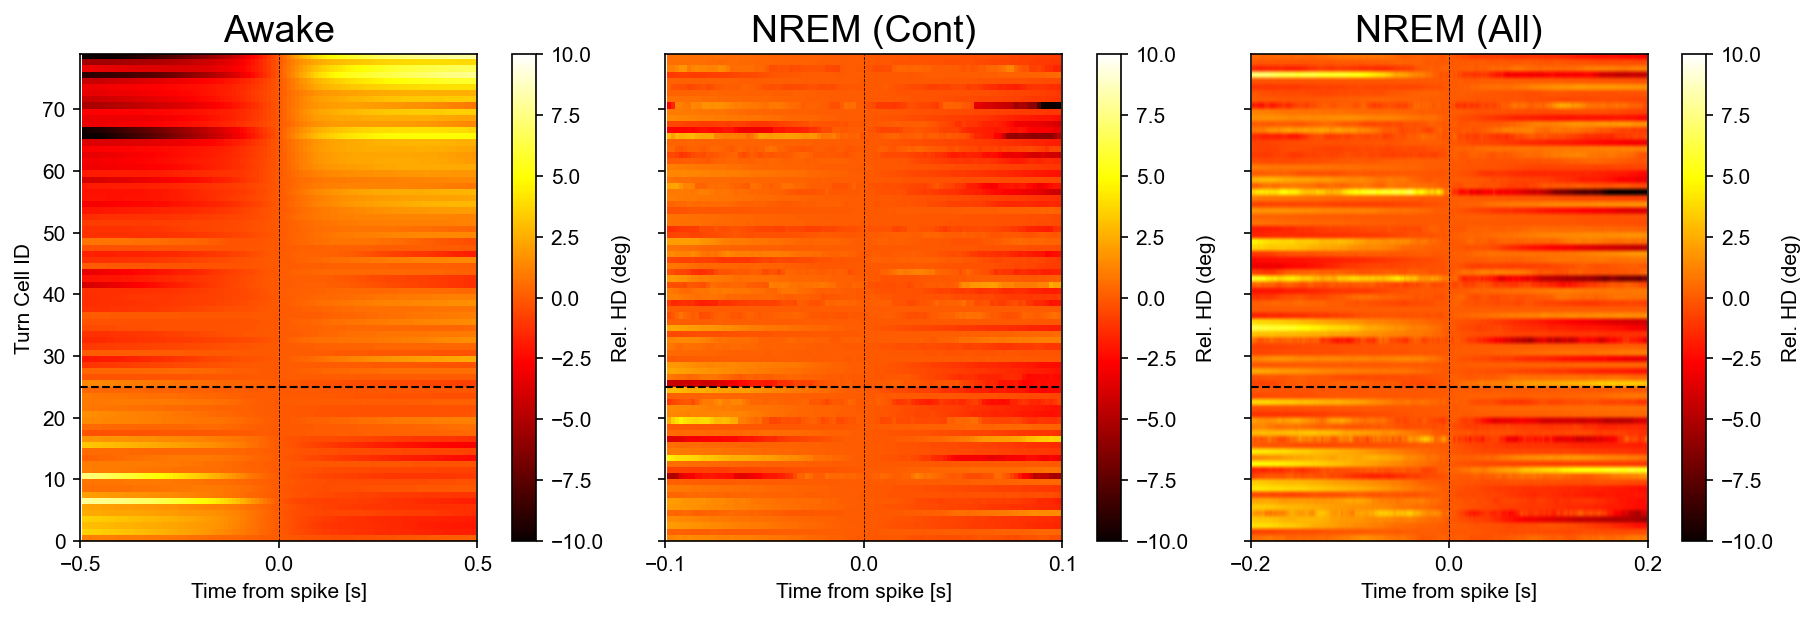

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem, sta_nrem_all], ["Awake", "NREM (Cont)", "NREM (All)"])):
    im = axes[i].imshow(
        sta[:, order].d.T,
        aspect='auto',
        origin='lower',
        extent=[sta.index[0], sta.index[-1], 0, sta.shape[1]],
        cmap='hot',
        norm=norm,
        )
    
    axes[i].axhline(y=zero_cross, color='k', linestyle='--', linewidth=1.)
    axes[i].axvline(x=0, color='k', linestyle='--', linewidth=0.4)
    
    plt.colorbar(im, ax=axes[i], label='Rel. HD (deg)')
    axes[i].set_title(f"{state}", fontsize=18)
    axes[i].set_xlabel("Time from spike [s]")

    
axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xticks([-0.5, 0, 0.5])
axes[1].set_xticks([-0.1, 0, 0.1])
axes[2].set_xticks([-0.2, 0, 0.2])
plt.show()
# plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_turn.png")

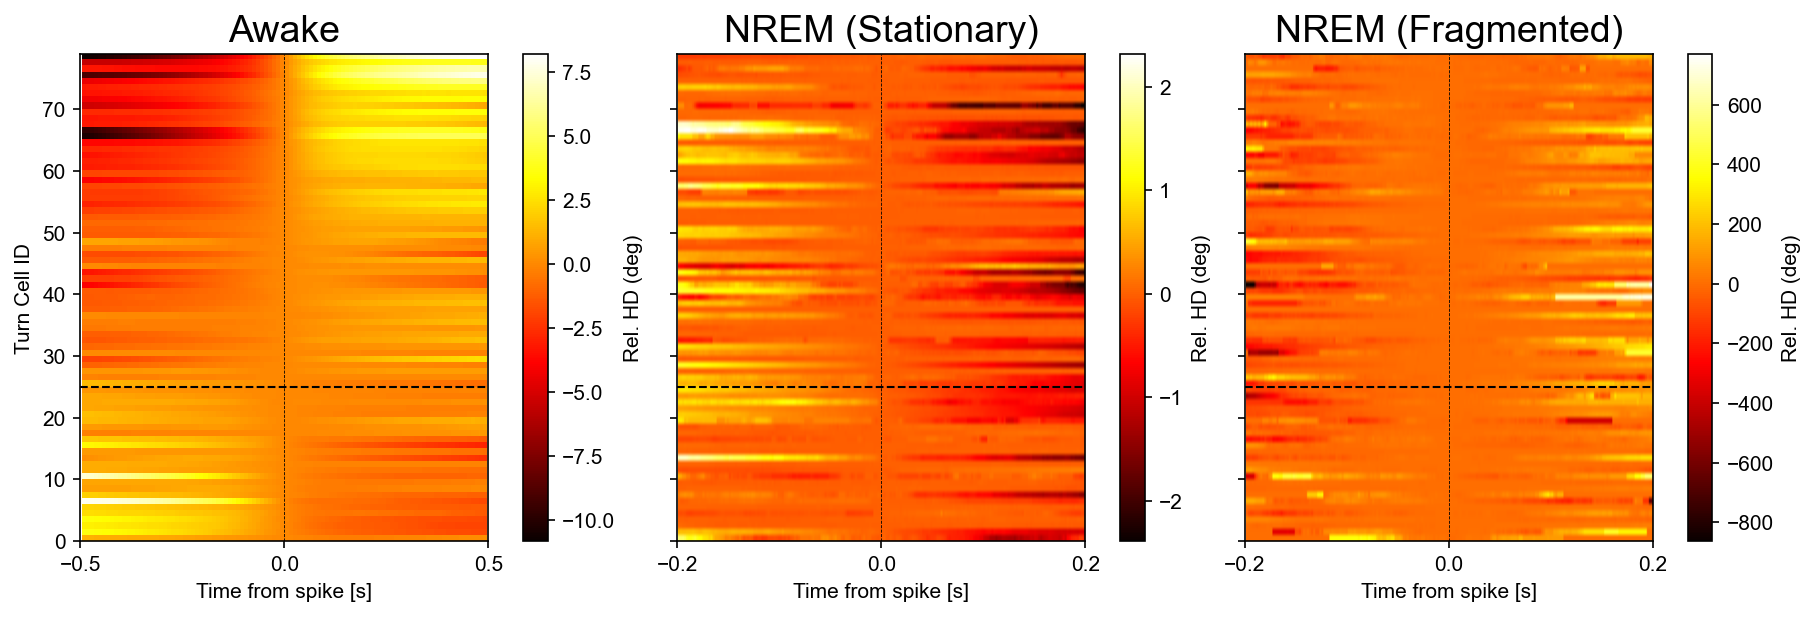

In [157]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem_stationary, sta_nrem_fragmented], ["Awake", "NREM (Stationary)", "NREM (Fragmented)"])):
    im = axes[i].imshow(
        sta[:, order].d.T,
        aspect='auto',
        origin='lower',
        extent=[sta.index[0], sta.index[-1], 0, sta.shape[1]],
        cmap='hot',
        # norm=norm,
        )
    
    axes[i].axhline(y=zero_cross, color='k', linestyle='--', linewidth=1.)
    axes[i].axvline(x=0, color='k', linestyle='--', linewidth=0.4)
    
    plt.colorbar(im, ax=axes[i], label='Rel. HD (deg)')
    axes[i].set_title(f"{state}", fontsize=18)
    axes[i].set_xlabel("Time from spike [s]")

    
axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xticks([-0.5, 0, 0.5])
axes[1].set_xticks([-0.2, 0, 0.2])
axes[2].set_xticks([-0.2, 0, 0.2])
plt.show()
# plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_turn.png")

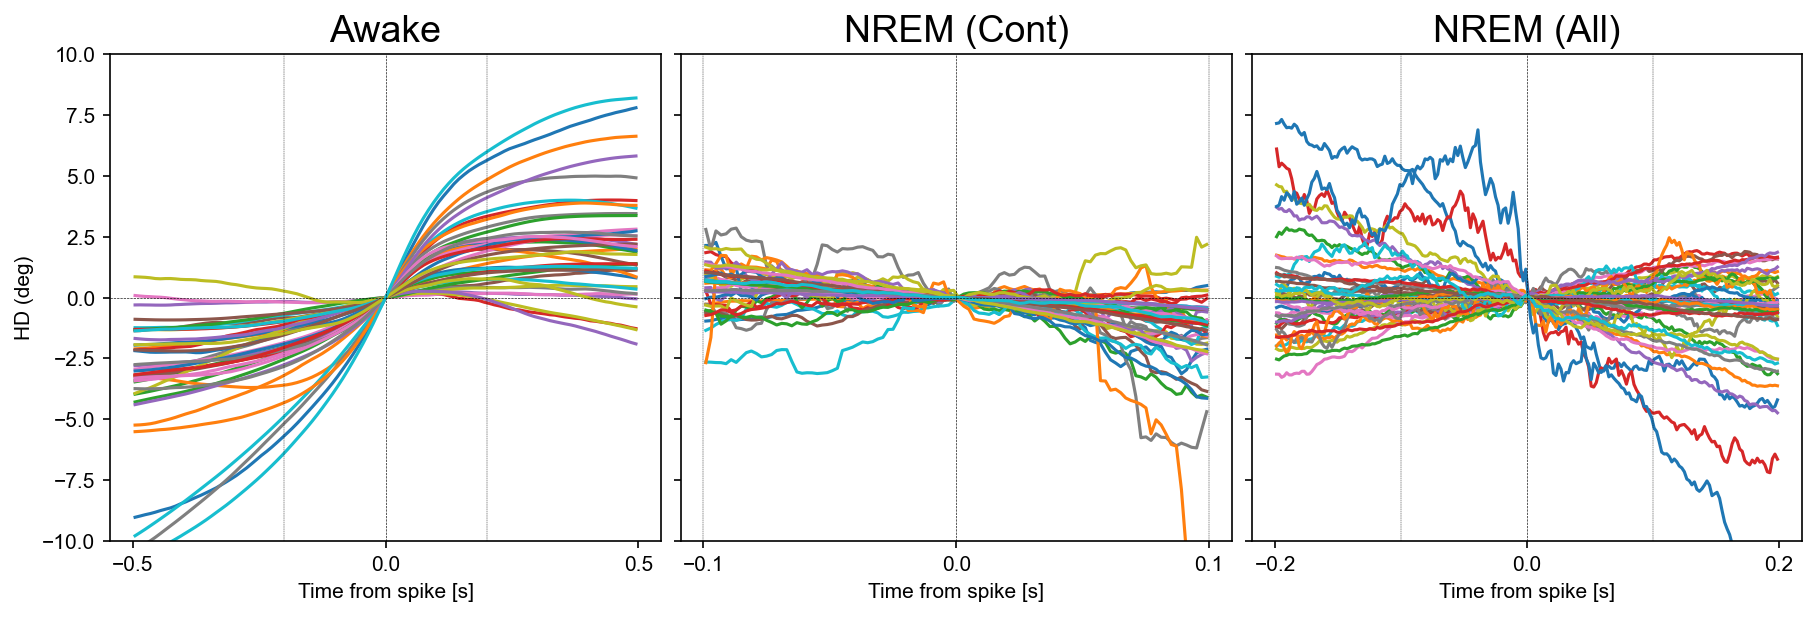

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes = axes.flatten()

mask = tsi>0.2

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem, sta_nrem_all], ["Awake", "NREM (Cont)", "NREM (All)"])):
    axes[i].plot(sta.index, sta[:, mask])
    axes[i].axhline(y=0, color='k', linestyle='--', linewidth=0.3)
    axes[i].axvline(x=0, color='k', linestyle='--', linewidth=0.3)
    if state == "Awake":
        axes[i].set_ylabel("HD (deg)")
        axes[i].set_ylim([-10, 10])
        axes[i].set_xticks([-0.5, 0, 0.5])
        axes[i].axvline(x=0.2, color='k', linestyle='--', linewidth=0.2)
        axes[i].axvline(x=-0.2, color='k', linestyle='--', linewidth=0.2)
        
    elif state == "NREM (Cont)":
        axes[i].set_ylim([-10, 10])
        axes[i].set_xticks([-0.1, 0, 0.1])
        axes[i].axvline(x=0.1, color='k', linestyle='--', linewidth=0.2)
        axes[i].axvline(x=-0.1, color='k', linestyle='--', linewidth=0.2)
    else:
        axes[i].set_ylim([-10, 10])
        axes[i].set_xticks([-0.2, 0, 0.2])
        axes[i].axvline(x=0.1, color='k', linestyle='--', linewidth=0.2)
        axes[i].axvline(x=-0.1, color='k', linestyle='--', linewidth=0.2)
    
    axes[i].set_title(f"{state}", fontsize=18)
    axes[i].set_xlabel("Time from spike [s]")
    
plt.show()
# plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_turn.png")

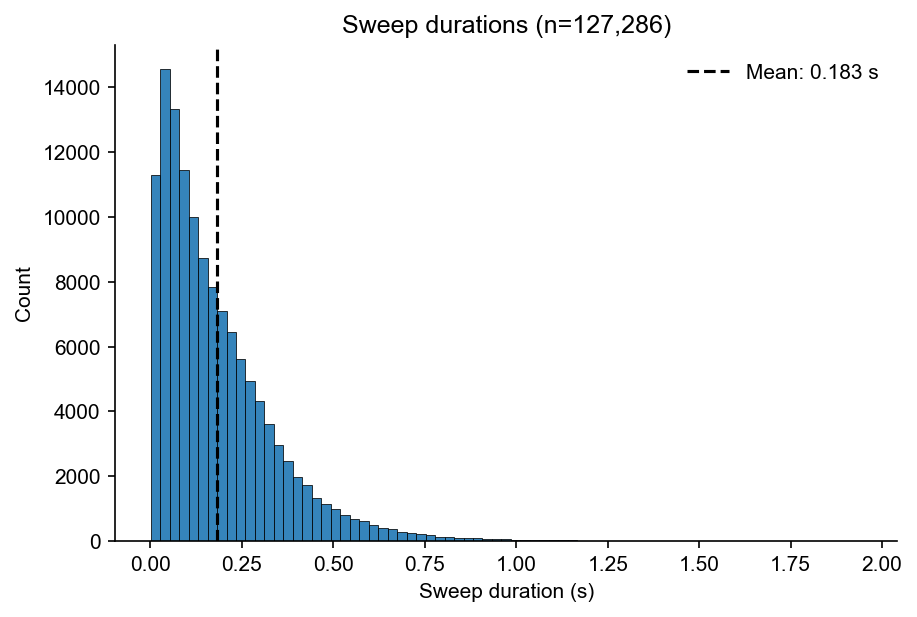

In [159]:
durations_s = np.concatenate([np.diff(sweep.time_support.values, axis=1) for sweep in sweeps])
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(durations_s, bins=75,
    # color="red",
    edgecolor="k",
    linewidth=0.4,
    alpha=0.9,
)

mean = np.mean(durations_s)
ax.axvline(
    mean,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean:.3g} s",
)

ax.set(
    xlabel="Sweep duration (s)",
    ylabel="Count",
    title=f"Sweep durations (n={durations_s.size:,})",
)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [ ]:
def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return sta[after_idx, :] - sta[before_idx, :]

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [289]:
turn_amps_awake = amplitude_at_threshold(sta_awake, sta_awake.t, 0.2)
turn_amps_nrem_all  = amplitude_at_threshold(sta_nrem_all, sta_nrem_all.t, 0.1)
turn_amps_nrem  = amplitude_at_threshold(sta_nrem, sta_nrem.t, 0.1)

Text(0.5, 0.98, 'Turn Amplitude vs TSI')

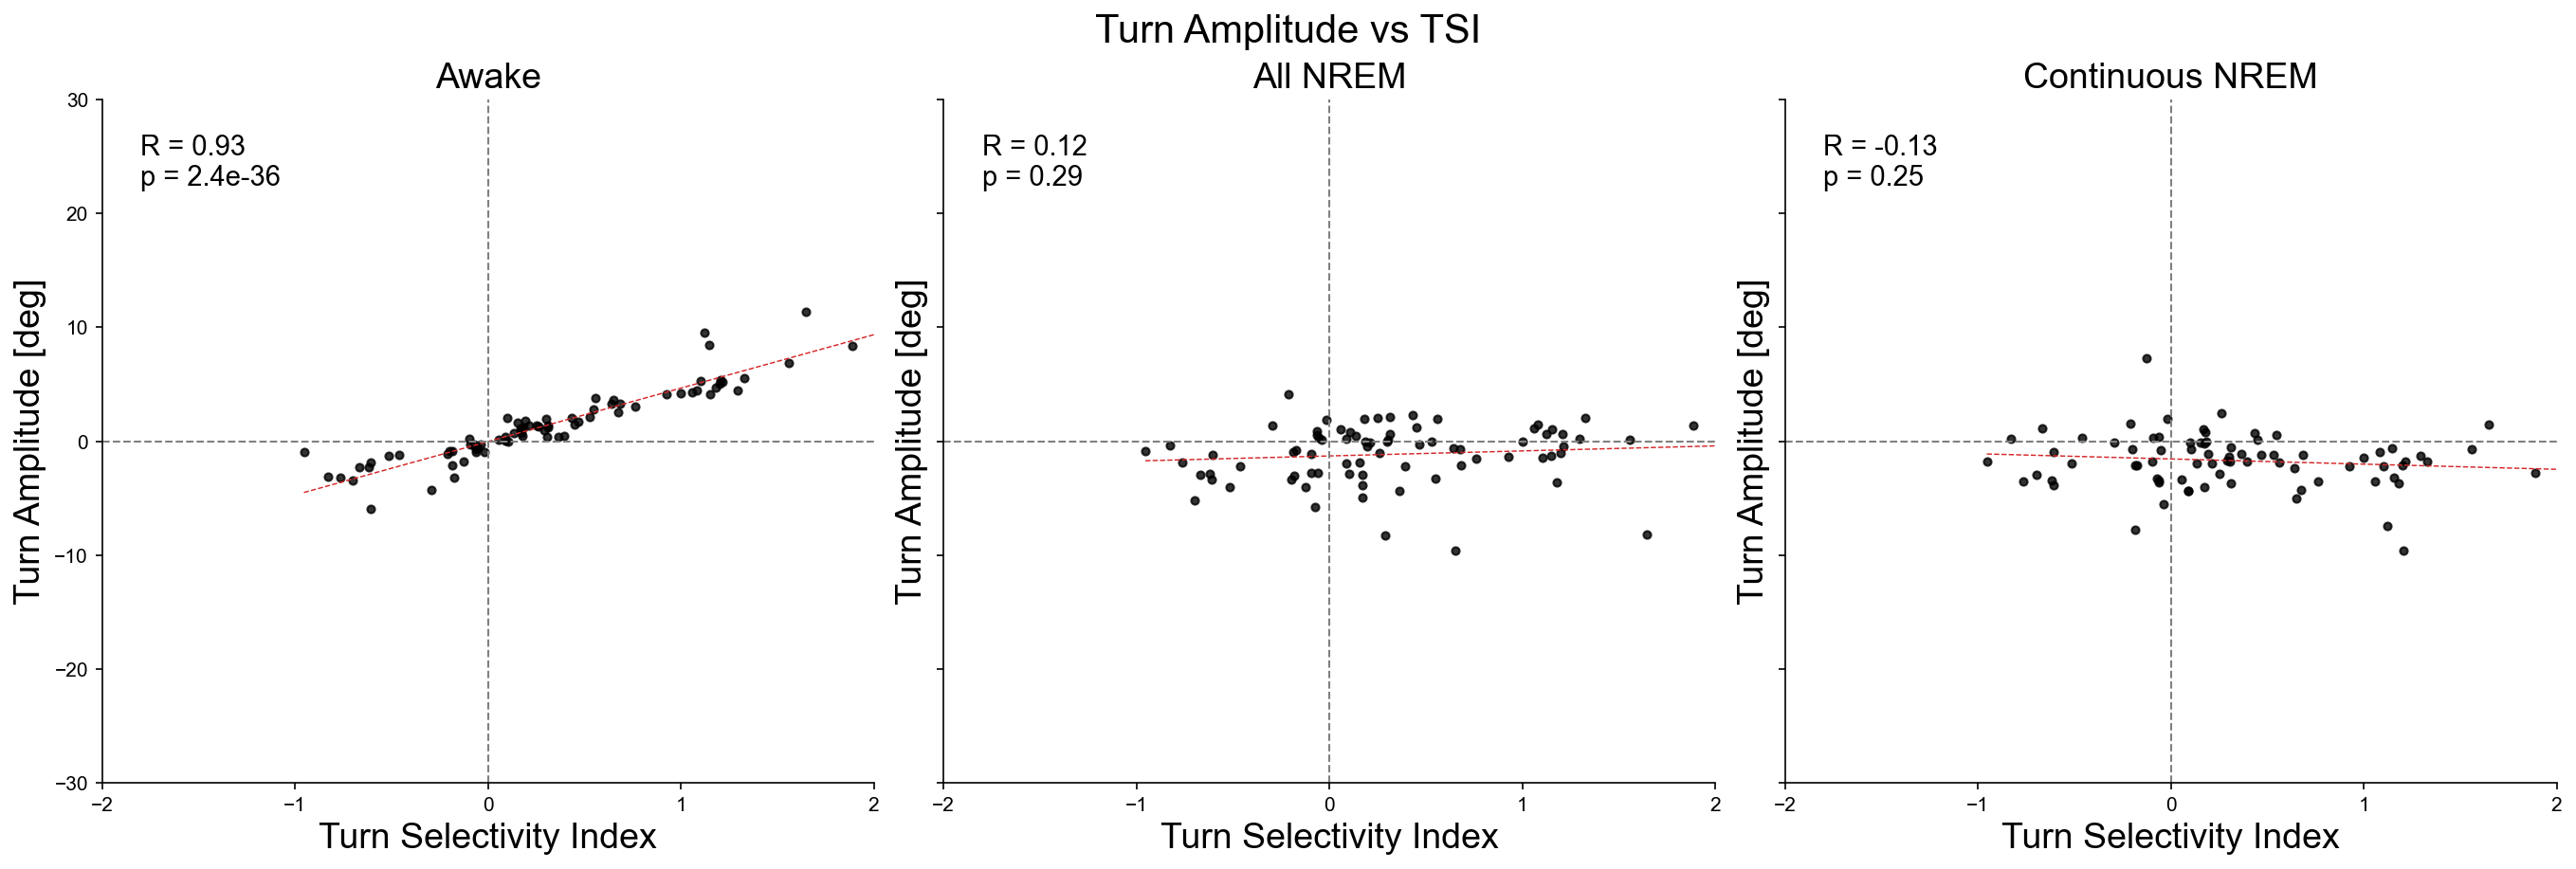

In [129]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True, constrained_layout=True)

plot_scatter_with_regression(axes[0], tsi, turn_amps_awake, 'Awake', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[1], tsi, turn_amps_nrem_all, 'All NREM', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[2], tsi, turn_amps_nrem, 'Continuous NREM', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')


for ax in axes:
    ax.set_xlim((-2, 2))
    ax.set_ylim((-30, 30))
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Turn Amplitude vs TSI", fontsize=20)

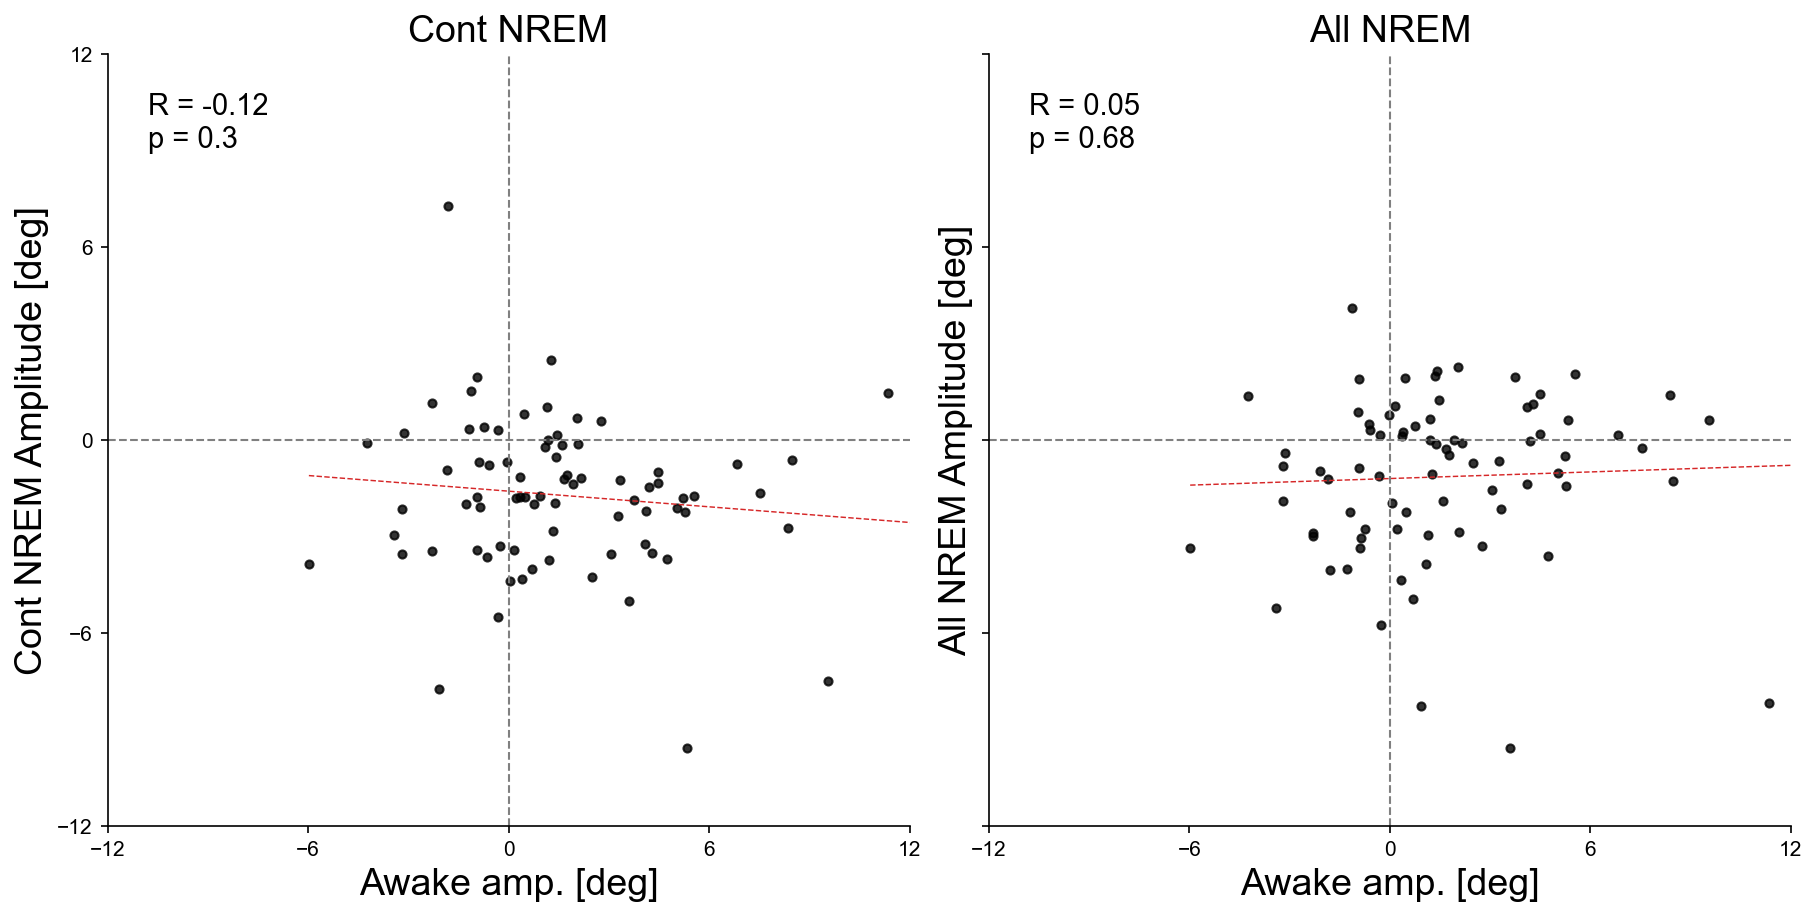

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True)

plot_scatter_with_regression(axes[0], x=turn_amps_awake, y=turn_amps_nrem, title='Cont NREM', xlabel='Awake amp. [deg]', ylabel='Cont NREM Amplitude [deg]')
plot_scatter_with_regression(axes[1], x=turn_amps_awake, y=turn_amps_nrem_all, title='All NREM', xlabel='Awake amp. [deg]', ylabel='All NREM Amplitude [deg]')

for ax in axes:
    ax.set_xlim((-12, 12))
    ax.set_ylim((-12, 12))
    ax.set_xticks([-12, -6, 0, 6, 12])
    ax.set_yticks([-12, -6, 0, 6, 12])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)